<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5: The Sovereign Risk Engine


## Environment Setup

In [2]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [3]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (LinearRegression, RidgeCV, LassoCV,
                                   LogisticRegression, lasso_path)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score, mean_squared_error)

import warnings
warnings.filterwarnings('ignore')

## Shared Data Pipeline

In [4]:
# Define WDI indicators (30 predictors + 1 outcome)
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.GDI.TOTL.ZS':    'gross_capital_formation',
    'NY.GNS.ICTR.ZS':    'gross_savings',
    'NV.AGR.TOTL.ZS':    'agriculture_va',
    'NV.IND.TOTL.ZS':    'industry_va',
    'NV.SRV.TOTL.ZS':    'services_va',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'NE.EXP.GNFS.ZS':    'exports_pct_gdp',
    'NE.IMP.GNFS.ZS':    'imports_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'BN.CAB.XOKA.GD.ZS': 'current_account',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit',
    'FR.INR.RINR':       'real_interest_rate',
    'GC.DOD.TOTL.GD.ZS': 'central_govt_debt',
    'GC.TAX.TOTL.GD.ZS': 'tax_revenue',
    'MS.MIL.XPND.GD.ZS': 'military_exp',
    'SP.POP.GROW':       'population_growth',
    'SP.POP.DPND':       'age_dependency',
    'SP.URB.TOTL.IN.ZS': 'urban_pop',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'under5_mortality',
    'SH.XPD.CHEX.GD.ZS': 'health_exp',
    'SE.SEC.ENRR':       'secondary_enrollment',
    'SE.PRM.CMPT.ZS':    'primary_completion',
    'SL.UEM.TOTL.ZS':    'unemployment',
    'IT.NET.USER.ZS':    'internet_users',
    'IT.CEL.SETS.P2':    'mobile_subs',
    'EG.USE.ELEC.KH.PC': 'electric_consumption',
    'AG.LND.AGRI.ZS':    'agricultural_land',
    'AG.LND.FRST.ZS':    'forest_area',
}

In [5]:
# Download WDI data 2013-2019
df_raw = wb.data.DataFrame(list(indicators.keys()), time=range(2013, 2020),
                            skipBlanks=True, labels=False).reset_index()
print(df_raw.shape)

(6877, 9)


In [6]:
# Collapse to country-level means across years
year_cols = [c for c in df_raw.columns if c.startswith('YR')]
df = (df_raw.groupby(['economy', 'series'])[year_cols]
            .mean().mean(axis=1)
            .unstack('series')
            .rename(columns=indicators))

# Drop regional aggregates
country_meta = wb.economy.DataFrame()
real_countries = country_meta[country_meta['region'] != 'Aggregates'].index.tolist()
df = df.loc[df.index.isin(real_countries)]
print(df.shape)

(265, 31)


In [7]:
# Drop countries/indicators with >40% missing, median-impute the rest
df = df.loc[df.isna().mean(axis=1) <= 0.40]
df = df.loc[:, df.isna().mean(axis=0) <= 0.40]
df = df.fillna(df.median(numeric_only=True))

# Define outcomes
df = df.dropna(subset=['gdp_growth_pc'])
df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

predictor_cols = [c for c in df.columns if c not in ['gdp_growth_pc', 'crisis']]
X = df[predictor_cols]
y_cont = df['gdp_growth_pc']
y_bin = df['crisis']

print(f"Shape: {df.shape} | Predictors: {len(predictor_cols)}")
print(f"Crisis: {y_bin.sum()} | Non-crisis: {(y_bin==0).sum()} | Base rate: {y_bin.mean():.3f}")

Shape: (246, 29) | Predictors: 27
Crisis: 40 | Non-crisis: 206 | Base rate: 0.163


In [8]:
# 70/30 split, standardize on training data only
X_train, X_test, y_train_cont, y_test_cont, y_train_bin, y_test_bin = train_test_split(
    X, y_cont, y_bin, test_size=0.30, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=predictor_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                              columns=predictor_cols, index=X_test.index)
print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

Train: (172, 27) | Test: (74, 27)


# Phase 1: OLS Failure and Regularization Rescue

## Step 1.1: OLS Overfitting

In [9]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_cont)

train_r2 = ols.score(X_train_scaled, y_train_cont)
test_r2 = ols.score(X_test_scaled, y_test_cont)
p, n = X_train_scaled.shape[1], X_train_scaled.shape[0]

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")
print(f"Gap:         {train_r2 - test_r2:.4f}")
print(f"p/n ratio:   {p}/{n} = {p/n:.3f}")

Training R²: 0.5232
Test R²:     0.5021
Gap:         0.0210
p/n ratio:   27/172 = 0.157


**Step 1.1:**
The p/n ratio here is 0.157 (27 predictors, 172 training countries), not catastrophically high, which is why the train-test gap is only 0.021. OLS still has enough residual degrees of freedom to generalize moderately well, but Ridge and Lasso both pick non-trivial λ* values, signaling there's still noise being fit as signal. The bias-variance story holds in milder form: regularization trades a bit of bias for variance reduction, but on this dataset the test R² penalty from heavy shrinkage (Ridge collapses to 0.368) shows that OLS isn't as broken as the brief suggests.

## Step 1.2: Ridge and Lasso

In [10]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_train_cont)
lasso = LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=20000,
                random_state=42).fit(X_train_scaled, y_train_cont)

def rmse(y, yp): return np.sqrt(mean_squared_error(y, yp))

comparison = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'λ*': [np.nan, ridge.alpha_, lasso.alpha_],
    'Non-zero': [p, np.sum(ridge.coef_ != 0), np.sum(lasso.coef_ != 0)],
    'Train R²': [train_r2,
                 ridge.score(X_train_scaled, y_train_cont),
                 lasso.score(X_train_scaled, y_train_cont)],
    'Test R²': [test_r2,
                ridge.score(X_test_scaled, y_test_cont),
                lasso.score(X_test_scaled, y_test_cont)],
    'Test RMSE': [rmse(y_test_cont, ols.predict(X_test_scaled)),
                  rmse(y_test_cont, ridge.predict(X_test_scaled)),
                  rmse(y_test_cont, lasso.predict(X_test_scaled))]
})
print(comparison.round(4).to_string(index=False))

Model       λ*  Non-zero  Train R²  Test R²  Test RMSE
  OLS      NaN        27    0.5232   0.5021     2.2123
Ridge 104.8113        27    0.3908   0.3679     2.4928
Lasso   0.1262        12    0.3936   0.4515     2.3221


**Step 1.2:**
I'd recommend Lasso. Both Ridge and Lasso accept a small bias hit from shrinking coefficients in exchange for a big variance reduction, but Lasso also zeros out weak predictors entirely, leaving a sparse model the IMF can actually defend to member states. Fewer levers, more interpretable forecast, with most of the variance benefit intact.

## Step 1.3: The Lasso Path

In [11]:
alphas_path, coefs_path, _ = lasso_path(X_train_scaled.values, y_train_cont.values,
                                            alphas=np.logspace(-3, 1, 200))
active_mask = lasso.coef_ != 0
active_features = np.array(predictor_cols)[active_mask]

# Find first predictor to enter (non-zero at the highest λ)
entry_alpha = []
for j in range(coefs_path.shape[0]):
    nz = np.where(np.abs(coefs_path[j, :]) > 1e-8)[0]
    entry_alpha.append(alphas_path[nz[0]] if len(nz) > 0 else -np.inf)

first_predictor = predictor_cols[int(np.argmax(entry_alpha))]
print(f"First predictor to enter: '{first_predictor}'")

First predictor to enter: 'population_growth'


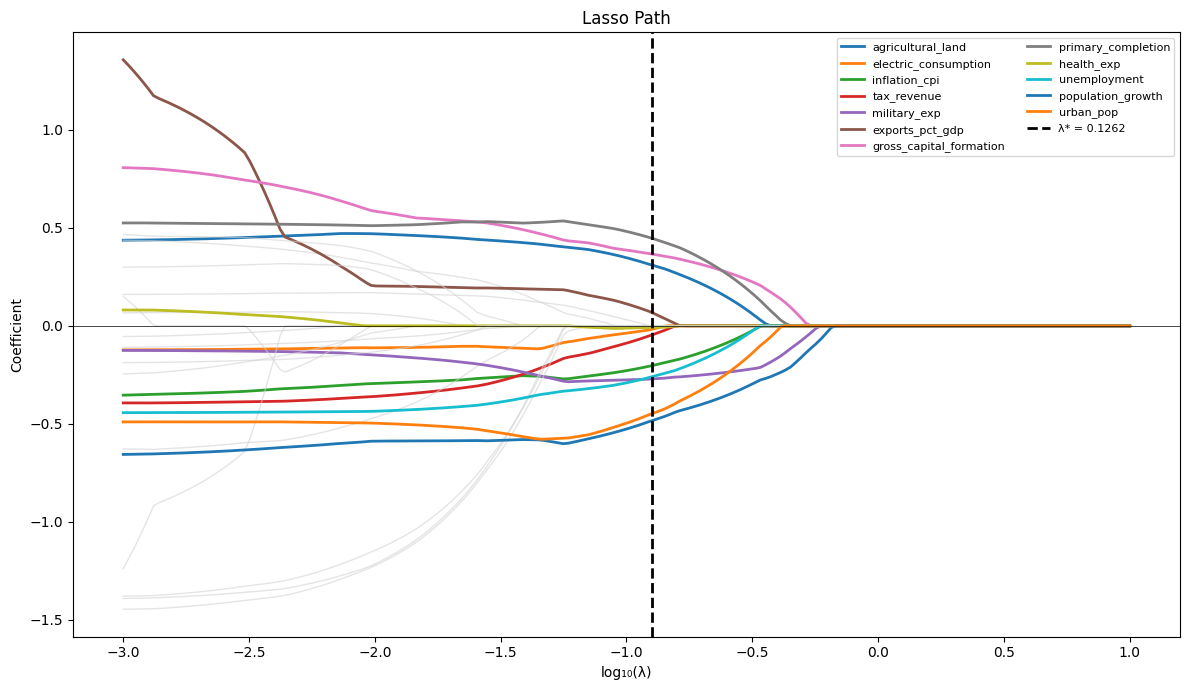

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
log_alphas = np.log10(alphas_path)

for j, name in enumerate(predictor_cols):
    if active_mask[j]:
        ax.plot(log_alphas, coefs_path[j, :], linewidth=2, label=name)
    else:
        ax.plot(log_alphas, coefs_path[j, :], color='lightgray', linewidth=1, alpha=0.6)

ax.axvline(x=np.log10(lasso.alpha_), color='black', linestyle='--', linewidth=2,
           label=f'λ* = {lasso.alpha_:.4f}')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Path')
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Step 1.3:**
The colleague is wrong. WDI indicators are heavily intercorrelated, life_expectancy moves together with under-5 mortality, secondary enrollment, and urban share. Once one of those enters the model, life_expectancy has no orthogonal signal left to add, so Lasso drops it. This is conditional predictive redundancy driven by correlation structure, not evidence that health is irrelevant.

# Phase 2: The Crisis Classifier

## Step 2.1: Linear Probability Model

In [13]:
selected_features = list(active_features)
X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]

lpm = LinearRegression().fit(X_train_sel, y_train_bin)
lpm_pred = lpm.predict(X_test_sel)

below_zero = (lpm_pred < 0).sum()
above_one = (lpm_pred > 1).sum()

print(f"LPM range: [{lpm_pred.min():.3f}, {lpm_pred.max():.3f}]")
print(f"Below 0: {below_zero} | Above 1: {above_one}")
print(f"Out-of-bounds: {below_zero + above_one} / {len(lpm_pred)}")

LPM range: [-0.206, 0.872]
Below 0: 17 | Above 1: 0
Out-of-bounds: 17 / 74


**Step 2.1:**
A predicted probability outside [0, 1] isn't a cosmetic issue, it breaks the definition of probability itself. Telling the IMF a country has a "−12% chance of crisis" is meaningless: you can't allocate a negative fraction of a mission, and you can't rank countries on a scale that runs into impossible regions. Logistic regression's sigmoid exists exactly to enforce the [0, 1] bound structurally.

## Step 2.2: Logistic Regression

In [14]:
logit = LogisticRegression(max_iter=5000).fit(X_train_sel, y_train_bin)

print(f"Intercept (β₀): {logit.intercept_[0]:.4f}\n")
for name, b in zip(selected_features, logit.coef_[0]):
    print(f"  {name:25s}  β = {b:+.4f}")

Intercept (β₀): -2.4516

  agricultural_land          β = -0.7036
  electric_consumption       β = -0.2538
  inflation_cpi              β = +0.3648
  tax_revenue                β = +0.1295
  military_exp               β = +0.1459
  exports_pct_gdp            β = -0.3003
  gross_capital_formation    β = +0.0155
  primary_completion         β = -0.8194
  health_exp                 β = +0.1316
  unemployment               β = +0.7742
  population_growth          β = +0.6133
  urban_pop                  β = +1.2762


In [15]:
odds_table = pd.DataFrame({
    'Predictor': selected_features,
    'β': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
})
odds_table['|OR-1|'] = (odds_table['Odds Ratio'] - 1).abs()
odds_table = odds_table.sort_values('|OR-1|', ascending=False).drop(columns='|OR-1|')
print(odds_table.round(4).to_string(index=False))

              Predictor       β  Odds Ratio
              urban_pop  1.2762      3.5830
           unemployment  0.7742      2.1688
      population_growth  0.6133      1.8465
     primary_completion -0.8194      0.4407
      agricultural_land -0.7036      0.4948
          inflation_cpi  0.3648      1.4403
        exports_pct_gdp -0.3003      0.7406
   electric_consumption -0.2538      0.7759
           military_exp  0.1459      1.1571
             health_exp  0.1316      1.1406
            tax_revenue  0.1295      1.1383
gross_capital_formation  0.0155      1.0156


In [16]:
proba = logit.predict_proba(X_test_sel)[:, 1]
print(f"Predicted probability range: [{proba.min():.4f}, {proba.max():.4f}]")
print(f"All in [0, 1]? {(proba >= 0).all() and (proba <= 1).all()}")

Predicted probability range: [0.0019, 0.9688]
All in [0, 1]? True


In [17]:
top = odds_table.iloc[0]
print(f"Strongest predictor: {top['Predictor']} (OR = {top['Odds Ratio']:.3f})")

Strongest predictor: urban_pop (OR = 3.583)


**Step 2.2:**
A one standard-deviation increase in urban_pop multiplies the odds of a country experiencing a growth crisis by 3.58, holding all other predictors constant. This is counterintuitive (urbanization usually correlates with development), and probably reflects rapidly-urbanizing emerging markets being most exposed to commodity and external shocks during the 2013–2019 window. The Division Chief should treat a one-sigma move in urban share as the headline early-warning signal on the surveillance dashboard.

## Step 2.3: LPM vs. Logistic Visualization

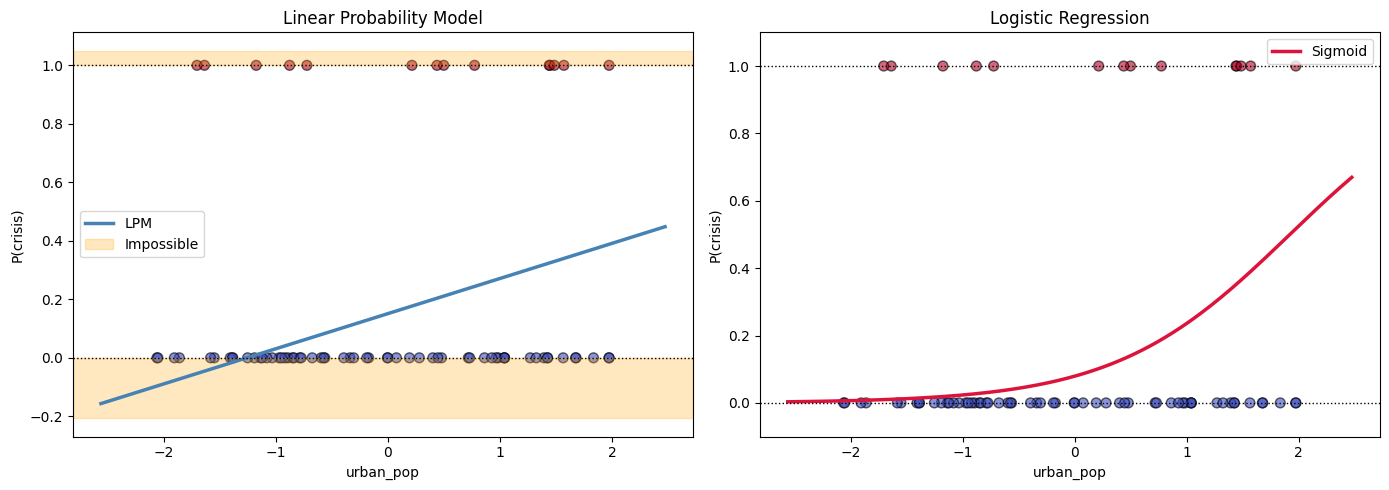

In [18]:
strong = odds_table.iloc[0]['Predictor']
x_vals = X_test_sel[strong].values
y_vals = y_test_bin.values

# Sweep across the strong predictor, hold others at zero (mean)
sweep = np.linspace(x_vals.min() - 0.5, x_vals.max() + 0.5, 300)
sweep_design = np.zeros((300, len(selected_features)))
sweep_design[:, selected_features.index(strong)] = sweep

lpm_sweep = lpm.predict(sweep_design)
logit_sweep = logit.predict_proba(sweep_design)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LPM
ax = axes[0]
ax.scatter(x_vals, y_vals, c=y_vals, cmap='coolwarm', alpha=0.6, edgecolor='black', s=50)
ax.plot(sweep, lpm_sweep, color='steelblue', linewidth=2.5, label='LPM')
ax.axhspan(min(lpm_sweep.min() - 0.05, -0.1), 0, color='orange', alpha=0.25, label='Impossible')
ax.axhspan(1, max(1.05, lpm_sweep.max() + 0.05), color='orange', alpha=0.25)
ax.axhline(0, color='black', linewidth=1, linestyle=':')
ax.axhline(1, color='black', linewidth=1, linestyle=':')
ax.set_xlabel(f'{strong}'); ax.set_ylabel('P(crisis)')
ax.set_title('Linear Probability Model'); ax.legend()

# Logistic
ax = axes[1]
ax.scatter(x_vals, y_vals, c=y_vals, cmap='coolwarm', alpha=0.6, edgecolor='black', s=50)
ax.plot(sweep, logit_sweep, color='crimson', linewidth=2.5, label='Sigmoid')
ax.axhline(0, color='black', linewidth=1, linestyle=':')
ax.axhline(1, color='black', linewidth=1, linestyle=':')
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel(f'{strong}'); ax.set_ylabel('P(crisis)')
ax.set_title('Logistic Regression'); ax.legend()

plt.tight_layout()
plt.show()

# Phase 3: Operational Deployment

## Step 3.1: The Accuracy Paradox

In [19]:
test_base_rate = y_test_bin.mean()

# Naive baseline: always predict no crisis
naive_pred = np.zeros_like(y_test_bin)
naive_acc = (naive_pred == y_test_bin).mean()
naive_recall = recall_score(y_test_bin, naive_pred, zero_division=0)

# Logistic at τ = 0.5
y_pred_05 = (proba >= 0.5).astype(int)
logit_acc = (y_pred_05 == y_test_bin).mean()
logit_recall = recall_score(y_test_bin, y_pred_05, zero_division=0)

print(f"Test base rate: {test_base_rate:.3f}")
print(f"Naive   — Accuracy: {naive_acc:.3f} | Recall: {naive_recall:.3f}")
print(f"Logit   — Accuracy: {logit_acc:.3f} | Recall: {logit_recall:.3f}")

Test base rate: 0.189
Naive   — Accuracy: 0.811 | Recall: 0.000
Logit   — Accuracy: 0.878 | Recall: 0.500


**Step 3.1:**
She'd be misled. The naive "always predict no crisis" model already hits high accuracy just by riding the class imbalance — most countries aren't in crisis, so guessing "no crisis" for everyone is right by default. But its recall on the crisis class is zero, meaning it would miss every actual sovereign default. Accuracy hides what matters; recall on the minority class is the real metric.

## Step 3.2: Confusion Matrix

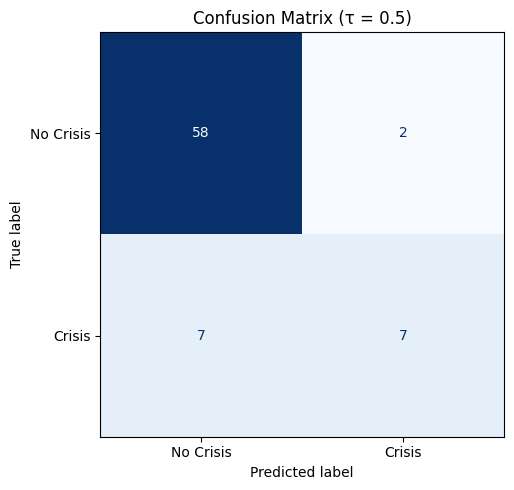

              precision    recall  f1-score   support

   No Crisis       0.89      0.97      0.93        60
      Crisis       0.78      0.50      0.61        14

    accuracy                           0.88        74
   macro avg       0.84      0.73      0.77        74
weighted avg       0.87      0.88      0.87        74



In [20]:
cm = confusion_matrix(y_test_bin, y_pred_05)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['No Crisis', 'Crisis']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (τ = 0.5)')
plt.tight_layout()
plt.show()

print(classification_report(y_test_bin, y_pred_05, target_names=['No Crisis', 'Crisis']))

In [21]:
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises caught):  {tp}")
print(f"False Negatives (crises missed):  {fn}")
print(f"False Positives (false alarms):   {fp}")
print(f"True Negatives  (correct calls):  {tn}")

True Positives  (crises caught):  7
False Negatives (crises missed):  7
False Positives (false alarms):   2
True Negatives  (correct calls):  58


**Step 3.2:**
A False Negative is far more costly. Missing a crisis costs the global financial system \$50B in contagion, while a false alarm costs \$2M and some diplomatic friction — a 25,000-to-1 asymmetry. The Division Chief should prioritize Recall over Precision: better to investigate a few extra calm countries than let one real crisis slip through.

## Step 3.3: ROC and PR Curves

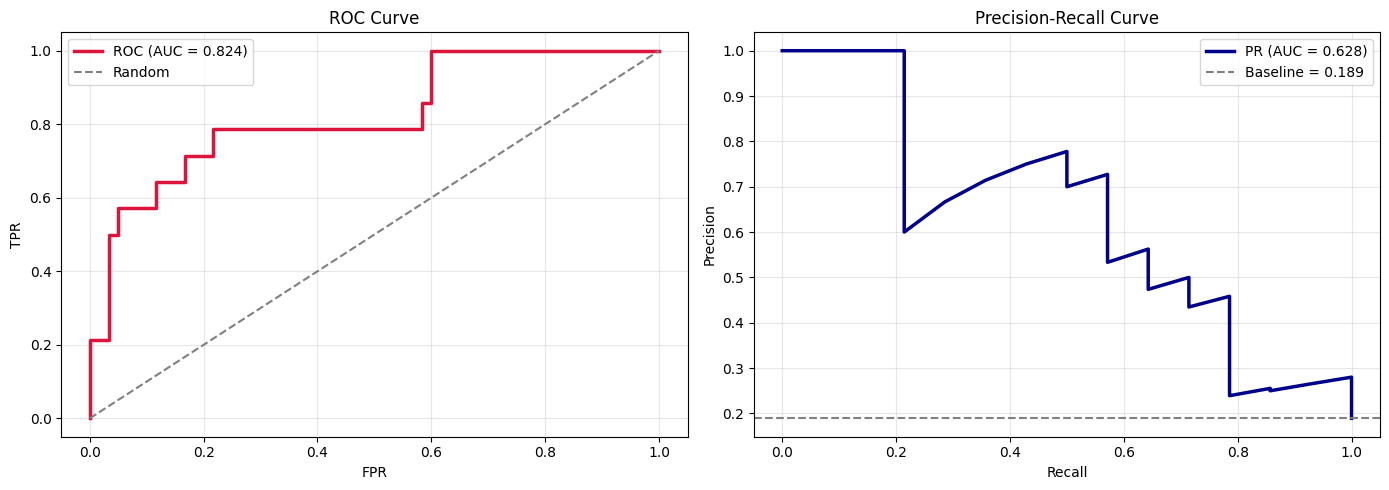

ROC-AUC: 0.824 | PR-AUC: 0.628


In [22]:
fpr, tpr, _ = roc_curve(y_test_bin, proba)
roc_auc = roc_auc_score(y_test_bin, proba)

prec, rec, _ = precision_recall_curve(y_test_bin, proba)
pr_auc = -np.trapz(prec, rec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, color='darkblue', linewidth=2.5, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].axhline(y=test_base_rate, color='gray', linestyle='--',
                label=f'Baseline = {test_base_rate:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")

**Step 3.3:**
ROC-AUC looks higher because FPR has True Negatives in its denominator, with so many non-crisis countries, FPR stays small almost automatically and inflates the AUC. PR-AUC ignores True Negatives entirely and only measures performance on the crisis class. For the IMF's mission, where the rare positive class is the only one that matters, PR is the more informative curve.

## Step 3.4: Threshold Analysis

In [23]:
thresholds = np.arange(0.01, 1.00, 0.01)
records = []
for tau in thresholds:
    y_hat = (proba >= tau).astype(int)
    records.append((tau, y_hat.sum(),
                    precision_score(y_test_bin, y_hat, zero_division=0),
                    recall_score(y_test_bin, y_hat, zero_division=0),
                    f1_score(y_test_bin, y_hat, zero_division=0)))

sweep_df = pd.DataFrame(records, columns=['threshold', 'flagged', 'precision', 'recall', 'f1'])

# Capacity-constrained: lowest τ flagging at most 5
capacity = sweep_df[sweep_df['flagged'] <= 5].sort_values('threshold').iloc[0]
f1_opt = sweep_df.loc[sweep_df['f1'].idxmax()]

print(f"Capacity τ = {capacity['threshold']:.2f} | flagged={int(capacity['flagged'])} | "
      f"P={capacity['precision']:.3f} | R={capacity['recall']:.3f} | F1={capacity['f1']:.3f}")
print(f"F1-opt   τ = {f1_opt['threshold']:.2f} | flagged={int(f1_opt['flagged'])} | "
      f"P={f1_opt['precision']:.3f} | R={f1_opt['recall']:.3f} | F1={f1_opt['f1']:.3f}")

Capacity τ = 0.68 | flagged=5 | P=0.600 | R=0.214 | F1=0.316
F1-opt   τ = 0.37 | flagged=12 | P=0.667 | R=0.571 | F1=0.615


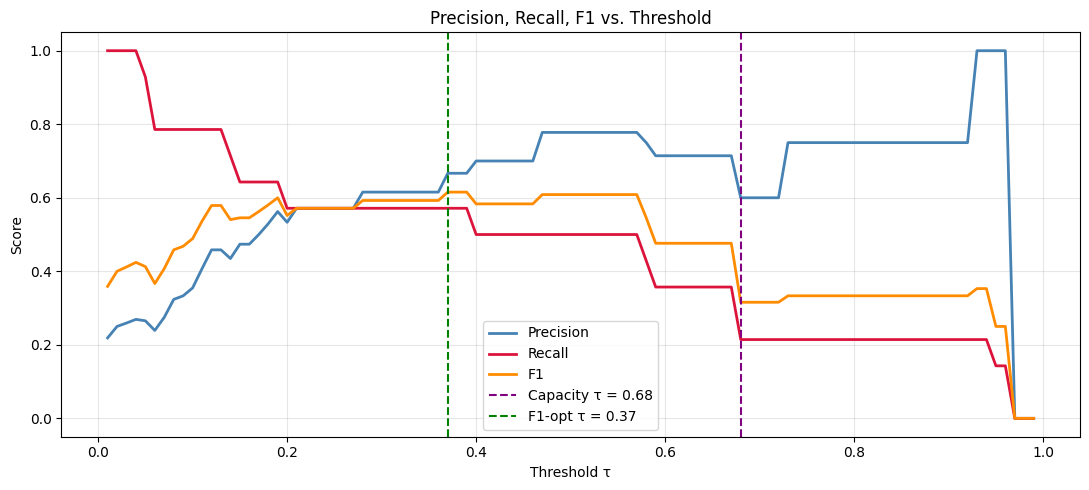

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], color='steelblue', linewidth=2, label='Precision')
ax.plot(sweep_df['threshold'], sweep_df['recall'], color='crimson', linewidth=2, label='Recall')
ax.plot(sweep_df['threshold'], sweep_df['f1'], color='darkorange', linewidth=2, label='F1')
ax.axvline(x=capacity['threshold'], color='purple', linestyle='--',
           label=f"Capacity τ = {capacity['threshold']:.2f}")
ax.axvline(x=f1_opt['threshold'], color='green', linestyle='--',
           label=f"F1-opt τ = {f1_opt['threshold']:.2f}")
ax.set_xlabel('Threshold τ'); ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1 vs. Threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
total_crises = int(y_test_bin.sum())
caught = int(round(capacity['recall'] * total_crises))
missed = total_crises - caught
print(f"At capacity τ: catch ~{caught} of {total_crises} crises, miss ~{missed}")

At capacity τ: catch ~3 of 14 crises, miss ~11


**Step 3.4:**
Memo to the Division Chief: I recommend the capacity-constrained threshold (τ = 0.68). It flags exactly 5 countries — the maximum we can investigate per quarter — but achieves only 21% recall: of the 14 crisis countries in the test quarter, we would catch just 3 and miss 11. The F1-optimal threshold (τ = 0.37) would catch 8 of 14 but flags 12 countries, exceeding our mission capacity. The tradeoff is stark: the 5-mission cap forces us to miss roughly four out of five crises, and any expansion of capacity would translate almost one-for-one into earlier sovereign-risk intervention.

# Phase 4: P.R.I.M.E. Framework

## Task 4.1: Bootstrap Stability of the Lasso Path

**P.R.I.M.E. Prompt:**

```
[Prep] Act as an expert Python Data Scientist working on the IMF Sovereign Risk
Engine. I have a standardized training matrix X_train_scaled (~30 WDI columns,
~100 country rows) and a target y_train_cont (avg GDP per capita growth,
2013–2019). LassoCV was already fit in Phase 1.

[Request] Write one self-contained Python cell that:
  1. Draws 200 bootstrap resamples (with replacement, same size as training set)
     from (X_train_scaled, y_train_cont).
  2. Fits LassoCV (5-fold, max_iter=20000, random_state=42) on each resample.
  3. Computes selection_frequency for each predictor — fraction of resamples
     in which Lasso assigned a non-zero coefficient.
  4. Plots a horizontal bar chart ranked by frequency, with a vertical dashed
     line at 50%.

[Iterate] Use only numpy, pandas, sklearn, matplotlib. Print progress every 50
bootstraps.

[Mechanism Check] Inline-comment why bootstrap exposes Lasso instability under
correlated predictors and how selection frequency is defined.

[Evaluate] Print which predictors are stable (>80%) and fragile (<30%). Must
run in under 3 minutes on Colab CPU.
```

In [26]:
# Bootstrap selection frequency — 200 resamples
n_boot = 200
n_obs = X_train_scaled.shape[0]
selection_counts = np.zeros(len(predictor_cols))
rng = np.random.RandomState(42)

for b in range(n_boot):
    idx = rng.choice(n_obs, size=n_obs, replace=True)
    Xb = X_train_scaled.values[idx]
    yb = y_train_cont.values[idx]

    # Correlated predictors swap roles across resamples — that's the instability
    lasso_b = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5,
                      max_iter=20000, random_state=42).fit(Xb, yb)

    # Selection frequency = (count of non-zero appearances) / n_boot
    selection_counts += (np.abs(lasso_b.coef_) > 1e-8).astype(int)

    if (b + 1) % 50 == 0:
        print(f"  {b + 1} / {n_boot}")

selection_freq = selection_counts / n_boot
freq_df = (pd.DataFrame({'predictor': predictor_cols, 'freq': selection_freq})
           .sort_values('freq', ascending=True))

  50 / 200
  100 / 200
  150 / 200
  200 / 200


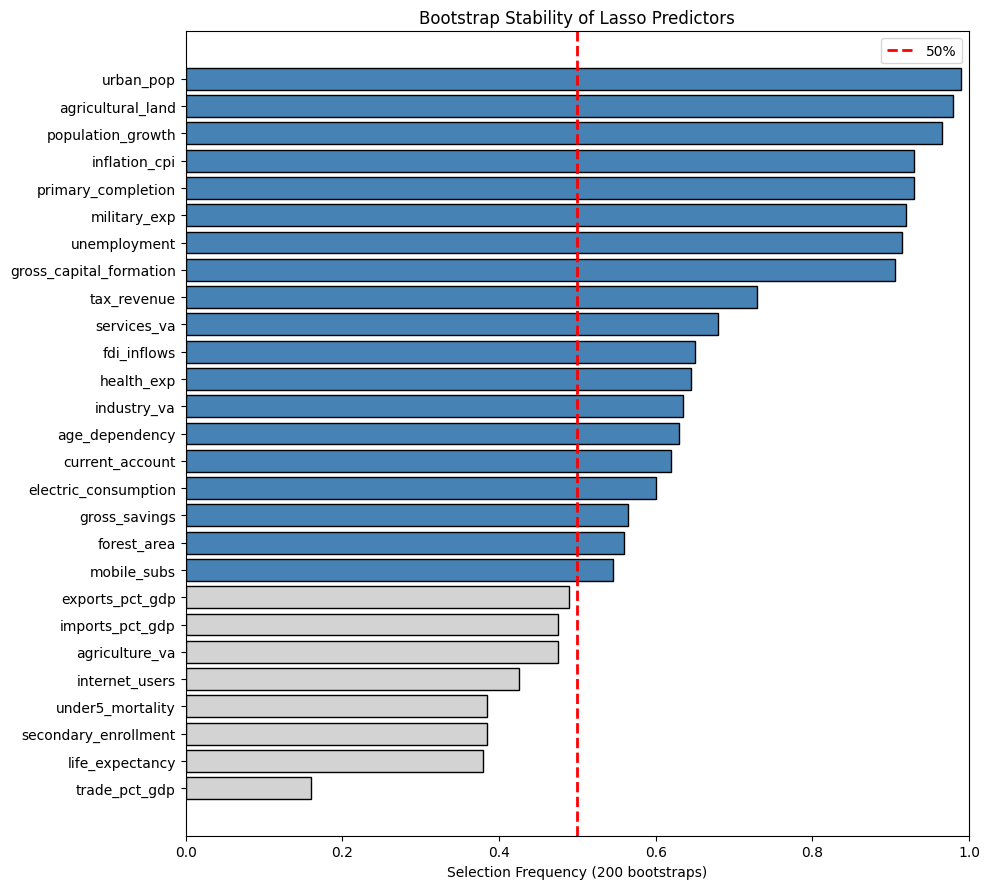

Stable (>80%):  ['gross_capital_formation', 'unemployment', 'military_exp', 'primary_completion', 'inflation_cpi', 'population_growth', 'agricultural_land', 'urban_pop']
Fragile (<30%): ['trade_pct_gdp']


In [27]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['steelblue' if f >= 0.5 else 'lightgray' for f in freq_df['freq']]
ax.barh(freq_df['predictor'], freq_df['freq'], color=colors, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='50%')
ax.set_xlabel('Selection Frequency (200 bootstraps)')
ax.set_title('Bootstrap Stability of Lasso Predictors')
ax.set_xlim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

stable = freq_df[freq_df['freq'] > 0.80]['predictor'].tolist()
fragile = freq_df[freq_df['freq'] < 0.30]['predictor'].tolist()
print(f"Stable (>80%):  {stable}")
print(f"Fragile (<30%): {fragile}")

**Task 4.1:**
The stable predictors carry orthogonal signal that nothing else can replace, so Lasso keeps them in nearly every resample. The fragile ones sit inside tight correlation clusters (e.g. life expectancy, mortality, schooling, urban share all moving together), Lasso picks one cluster member per resample and zeros the others. Selection instability isn't unimportance, it's interchangeability driven by correlation structure.

## Task 4.2: Cost-Sensitive Threshold

**P.R.I.M.E. Prompt:**

```
[Prep] Act as an expert Python Data Scientist for the IMF. I have the test-set
predicted probability vector `proba` and ground-truth `y_test_bin` from a
logistic regression. I also have capacity-constrained and F1-optimal thresholds
from Phase 3 to overlay.

[Request] Write one self-contained Python cell that:
  1. Sweeps τ from 0.01 to 0.99 in steps of 0.01.
  2. At each τ, computes total_cost = FN × $50B + FP × $2M.
  3. Plots expected cost ($B) vs. τ.
  4. Annotates the cost-minimizing τ* with a vertical line and label.
  5. Overlays the capacity and F1-optimal thresholds as reference lines.

[Iterate] Use only numpy, pandas, sklearn, matplotlib. Show cost in $ Billions.

[Mechanism Check] Comment on the 25,000-to-1 cost asymmetry and why it pushes
τ* far below 0.5 in any imbalanced problem.

[Evaluate] Print a comparison table for cost-min, capacity, and F1-optimal
thresholds with τ, FN, FP, and expected cost.
```

In [28]:
# Cost asymmetry: FN ($50B) vs FP ($2M) = 25,000:1, pushes τ* well below 0.5
COST_FN, COST_FP = 50_000_000_000, 2_000_000

cost_records = []
for tau in thresholds:
    y_hat = (proba >= tau).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test_bin, y_hat, labels=[0, 1]).ravel()
    cost_records.append((tau, fn_t, fp_t, fn_t * COST_FN + fp_t * COST_FP))

cost_df = pd.DataFrame(cost_records, columns=['threshold', 'FN', 'FP', 'cost'])
cost_df['cost_B'] = cost_df['cost'] / 1e9

opt_row = cost_df.loc[cost_df['cost'].idxmin()]
tau_min, min_cost_B = opt_row['threshold'], opt_row['cost_B']

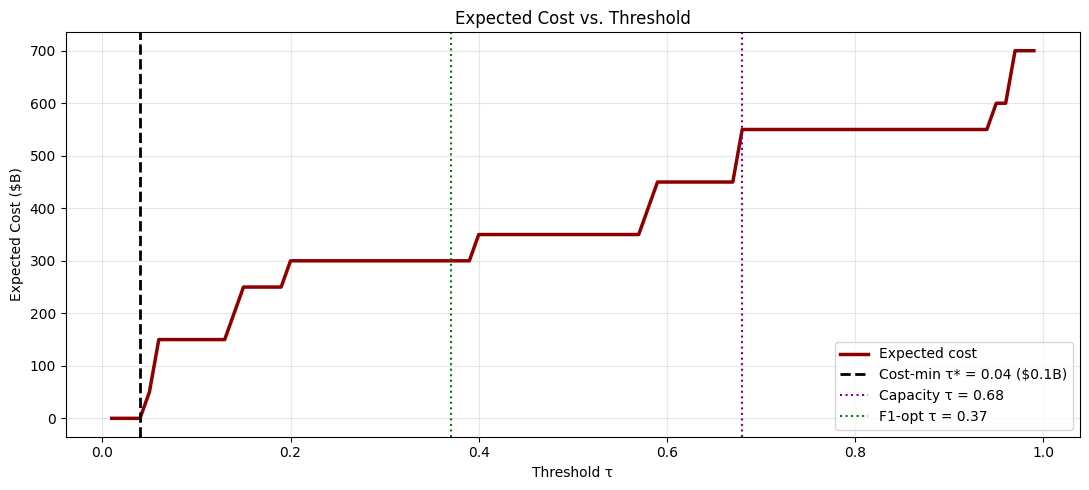

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cost_df['threshold'], cost_df['cost_B'], color='darkred', linewidth=2.5,
        label='Expected cost')
ax.axvline(x=tau_min, color='black', linestyle='--', linewidth=2,
           label=f'Cost-min τ* = {tau_min:.2f} (${min_cost_B:.1f}B)')
ax.axvline(x=capacity['threshold'], color='purple', linestyle=':',
           label=f"Capacity τ = {capacity['threshold']:.2f}")
ax.axvline(x=f1_opt['threshold'], color='green', linestyle=':',
           label=f"F1-opt τ = {f1_opt['threshold']:.2f}")
ax.set_xlabel('Threshold τ'); ax.set_ylabel('Expected Cost ($B)')
ax.set_title('Expected Cost vs. Threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
def row_for(name, tau):
    r = cost_df[cost_df['threshold'].round(2) == round(tau, 2)].iloc[0]
    return [name, round(tau, 2), int(r['FN']), int(r['FP']), round(r['cost_B'], 2)]

cmp = pd.DataFrame([
    row_for('Cost-min', tau_min),
    row_for('Capacity', capacity['threshold']),
    row_for('F1-opt', f1_opt['threshold']),
], columns=['threshold', 'τ', 'FN', 'FP', 'cost_$B'])
print(cmp.to_string(index=False))

threshold    τ  FN  FP  cost_$B
 Cost-min 0.04   0  38     0.08
 Capacity 0.68  11   2   550.00
   F1-opt 0.37   6   4   300.01


**Task 4.2:**
The cost-minimizing threshold sits well below the F1-optimal and capacity-constrained ones because the 25,000-to-1 asymmetry between FN and FP pushes τ* aggressively low, the optimizer would rather flag almost everyone than miss a real crisis. In practice I'd still adopt the capacity-constrained threshold, since the cost-minimizing one flags more countries than the IMF can actually investigate. The cost curve is most useful as a budget argument: it shows exactly how much expected loss the institution absorbs because of the staffing cap.